In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import TRAIN_A, TRAIN_B, RESULTS_DIR

print("Training Set A:", TRAIN_A)
print("Training Set B:", TRAIN_B)
print("Results:", RESULTS_DIR)

Training Set A: C:\TwinSepsis\dataset\physionet.org\files\challenge-2019\1.0.0\training\training_setA
Training Set B: C:\TwinSepsis\dataset\physionet.org\files\challenge-2019\1.0.0\training\training_setB
Results: C:\TwinSepsis\results


In [2]:
train_ids = pd.read_csv(
    RESULTS_DIR / "train_patient_ids.csv"
)["patient_id"].tolist()

val_ids = pd.read_csv(
    RESULTS_DIR / "val_patient_ids.csv"
)["patient_id"].tolist()

test_ids = pd.read_csv(
    RESULTS_DIR / "test_patient_ids.csv"
)["patient_id"].tolist()

print("Training patients:", len(train_ids))
print("Validation patients:", len(val_ids))
print("Test patients:", len(test_ids))

Training patients: 28235
Validation patients: 6050
Test patients: 6051


In [3]:
all_patient_files = {}

for file_path in TRAIN_A.glob("*.psv"):
    all_patient_files[file_path.stem] = file_path

for file_path in TRAIN_B.glob("*.psv"):
    all_patient_files[file_path.stem] = file_path

print("Total patient files:", len(all_patient_files))

print(
    "Missing train:",
    sum(pid not in all_patient_files for pid in train_ids)
)

print(
    "Missing validation:",
    sum(pid not in all_patient_files for pid in val_ids)
)

print(
    "Missing test:",
    sum(pid not in all_patient_files for pid in test_ids)
)

Total patient files: 40336
Missing train: 0
Missing validation: 0
Missing test: 0


In [4]:
sample_file = all_patient_files[train_ids[0]]

sample_df = pd.read_csv(
    sample_file,
    sep="|",
    nrows=5
)

sofa_variables = [
    "PaO2",
    "FiO2",
    "Platelets",
    "Bilirubin_total",
    "MAP",
    "Creatinine",
    "UrineOutput",
    "GCS",
    "Norepinephrine",
    "Epinephrine",
    "Dopamine",
    "Dobutamine"
]

availability_df = pd.DataFrame({
    "SOFA_variable": sofa_variables,
    "Available_in_dataset": [
        variable in sample_df.columns
        for variable in sofa_variables
    ]
})

display(availability_df)

,SOFA_variable,Available_in_dataset
0,PaO2,False
1,FiO2,True
2,Platelets,True
3,Bilirubin_total,True
4,MAP,True
5,Creatinine,True
6,UrineOutput,False
7,GCS,False
8,Norepinephrine,False
9,Epinephrine,False


In [5]:
# CELL 5 — SOFA VARIABLE MISSINGNESS

sofa_available_vars = [
    "FiO2",
    "Platelets",
    "Bilirubin_total",
    "MAP",
    "Creatinine",
]

sample_patient_files = list(all_patient_files.values())[:100]

missingness_rows = []

for file_path in sample_patient_files:
    df = pd.read_csv(file_path, sep="|")

    for variable in sofa_available_vars:
        missingness_rows.append({
            "Variable": variable,
            "Missing": df[variable].isna().sum(),
            "Total": len(df),
        })

missingness_df = pd.DataFrame(missingness_rows)

missingness_summary = (
    missingness_df
    .groupby("Variable")
    .agg(
        Missing=("Missing", "sum"),
        Total=("Total", "sum")
    )
)

missingness_summary["Missing_Rate"] = (
    missingness_summary["Missing"] /
    missingness_summary["Total"]
)

display(
    missingness_summary.style.format({
        "Missing_Rate": "{:.2%}"
    })
)

,Missing,Total,Missing_Rate
Variable,,,
Bilirubin_total,3655,3704,98.68%
Creatinine,3441,3704,92.90%
FiO2,3228,3704,87.15%
MAP,389,3704,10.50%
Platelets,3458,3704,93.36%


In [6]:
# CELL 6 — AVAILABLE SOFA COMPONENT SCORING

def platelet_score(x):
    if pd.isna(x):
        return np.nan
    if x >= 150:
        return 0
    elif x >= 100:
        return 1
    elif x >= 50:
        return 2
    elif x >= 20:
        return 3
    else:
        return 4


def bilirubin_score(x):
    if pd.isna(x):
        return np.nan
    if x < 1.2:
        return 0
    elif x < 2.0:
        return 1
    elif x < 6.0:
        return 2
    elif x <= 12.0:
        return 3
    else:
        return 4


def map_score(x):
    if pd.isna(x):
        return np.nan
    if x >= 70:
        return 0
    else:
        return 1


def creatinine_score(x):
    if pd.isna(x):
        return np.nan
    if x < 1.2:
        return 0
    elif x < 2.0:
        return 1
    elif x < 3.5:
        return 2
    elif x <= 5.0:
        return 3
    else:
        return 4


print("SOFA scoring functions created successfully.")

SOFA scoring functions created successfully.


In [7]:
# CELL 7 — BUILD PARTIAL SOFA SCORES

def load_patients(patient_ids):
    frames = []

    for i, patient_id in enumerate(patient_ids):
        file_path = all_patient_files[patient_id]

        df = pd.read_csv(file_path, sep="|")

        df["patient_id"] = patient_id

        frames.append(df)

        if (i + 1) % 1000 == 0:
            print(f"Loaded {i + 1:,} patients...")

    return pd.concat(frames, ignore_index=True)


# Load validation and test patients
print("Loading validation patients...")
sofa_val_df = load_patients(val_ids)

print("\nLoading test patients...")
sofa_test_df = load_patients(test_ids)

print("\nValidation shape:", sofa_val_df.shape)
print("Test shape:", sofa_test_df.shape)

Loading validation patients...
Loaded 1,000 patients...
Loaded 2,000 patients...
Loaded 3,000 patients...
Loaded 4,000 patients...
Loaded 5,000 patients...
Loaded 6,000 patients...

Loading test patients...
Loaded 1,000 patients...
Loaded 2,000 patients...
Loaded 3,000 patients...
Loaded 4,000 patients...
Loaded 5,000 patients...
Loaded 6,000 patients...

Validation shape: (231472, 42)
Test shape: (234302, 42)


In [8]:
# CELL 8 — CALCULATE PARTIAL SOFA COMPONENTS

def add_sofa_components(df):
    df = df.copy()

    # Available SOFA components
    df["SOFA_Coagulation"] = df["Platelets"].apply(platelet_score)
    df["SOFA_Liver"] = df["Bilirubin_total"].apply(bilirubin_score)
    df["SOFA_Cardiovascular"] = df["MAP"].apply(map_score)
    df["SOFA_Renal"] = df["Creatinine"].apply(creatinine_score)

    return df


sofa_val_df = add_sofa_components(sofa_val_df)
sofa_test_df = add_sofa_components(sofa_test_df)

print("Validation components added.")
print("Test components added.")

display(
    sofa_val_df[
        [
            "Platelets",
            "SOFA_Coagulation",
            "Bilirubin_total",
            "SOFA_Liver",
            "MAP",
            "SOFA_Cardiovascular",
            "Creatinine",
            "SOFA_Renal",
        ]
    ].head(10)
)

Validation components added.
Test components added.


,Platelets,SOFA_Coagulation,Bilirubin_total,SOFA_Liver,MAP,SOFA_Cardiovascular,Creatinine,SOFA_Renal
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,87.0,0.0,NaN,NaN
2,NaN,NaN,NaN,NaN,119.0,0.0,NaN,NaN
3,NaN,NaN,NaN,NaN,107.0,0.0,NaN,NaN
4,NaN,NaN,NaN,NaN,99.5,0.0,NaN,NaN
5,NaN,NaN,NaN,NaN,101.0,0.0,NaN,NaN
6,NaN,NaN,NaN,NaN,99.0,0.0,NaN,NaN
7,NaN,NaN,NaN,NaN,103.0,0.0,NaN,NaN
8,NaN,NaN,NaN,NaN,96.0,0.0,NaN,NaN
9,NaN,NaN,NaN,NaN,107.0,0.0,NaN,NaN


In [9]:
# CELL 9 — PARTIAL SOFA SCORE + COMPONENT AVAILABILITY

sofa_components = [
    "SOFA_Coagulation",
    "SOFA_Liver",
    "SOFA_Cardiovascular",
    "SOFA_Renal",
]


def add_partial_sofa(df):
    df = df.copy()

    # Number of SOFA components that were actually measurable
    df["SOFA_Components_Available"] = (
        df[sofa_components]
        .notna()
        .sum(axis=1)
    )

    # Sum only the components that are available.
    # Missing components remain excluded, NOT treated as normal.
    df["Partial_SOFA"] = df[sofa_components].sum(
        axis=1,
        min_count=1
    )

    return df


sofa_val_df = add_partial_sofa(sofa_val_df)
sofa_test_df = add_partial_sofa(sofa_test_df)

print("Partial SOFA calculated.")

display(
    sofa_val_df[
        [
            "SOFA_Coagulation",
            "SOFA_Liver",
            "SOFA_Cardiovascular",
            "SOFA_Renal",
            "SOFA_Components_Available",
            "Partial_SOFA",
            "SepsisLabel",
        ]
    ].head(20)
)

Partial SOFA calculated.


,SOFA_Coagulation,SOFA_Liver,SOFA_Cardiovascular,SOFA_Renal,SOFA_Components_Available,Partial_SOFA,SepsisLabel
0,NaN,NaN,NaN,NaN,0,NaN,0
1,NaN,NaN,0.0,NaN,1,0.0,0
2,NaN,NaN,0.0,NaN,1,0.0,0
3,NaN,NaN,0.0,NaN,1,0.0,0
4,NaN,NaN,0.0,NaN,1,0.0,0
5,NaN,NaN,0.0,NaN,1,0.0,0
6,NaN,NaN,0.0,NaN,1,0.0,0
7,NaN,NaN,0.0,NaN,1,0.0,0
8,NaN,NaN,0.0,NaN,1,0.0,0
9,NaN,NaN,0.0,NaN,1,0.0,0


In [10]:
# CELL 10 — COMPONENT AVAILABILITY DISTRIBUTION

availability_counts = (
    sofa_val_df["SOFA_Components_Available"]
    .value_counts()
    .sort_index()
)

availability_percent = (
    availability_counts /
    len(sofa_val_df) * 100
)

availability_summary = pd.DataFrame({
    "Rows": availability_counts,
    "Percentage": availability_percent
})

display(
    availability_summary.style.format({
        "Rows": "{:,.0f}",
        "Percentage": "{:.2f}%"
    })
)

,Rows,Percentage
SOFA_Components_Available,,
0,"27,370",11.82%
1,"188,366",81.38%
2,"4,358",1.88%
3,"8,547",3.69%
4,"2,831",1.22%


In [11]:
# CELL 11 — VALIDATION VS TEST SOFA COVERAGE

val_coverage = (
    sofa_val_df["SOFA_Components_Available"]
    .value_counts()
    .sort_index()
)

test_coverage = (
    sofa_test_df["SOFA_Components_Available"]
    .value_counts()
    .sort_index()
)

coverage_comparison = pd.DataFrame({
    "Validation_Rows": val_coverage,
    "Validation_%": val_coverage / len(sofa_val_df) * 100,
    "Test_Rows": test_coverage,
    "Test_%": test_coverage / len(sofa_test_df) * 100,
}).fillna(0)

display(
    coverage_comparison.style.format({
        "Validation_Rows": "{:,.0f}",
        "Validation_%": "{:.2f}%",
        "Test_Rows": "{:,.0f}",
        "Test_%": "{:.2f}%"
    })
)

,Validation_Rows,Validation_%,Test_Rows,Test_%
SOFA_Components_Available,,,,
0,"27,370",11.82%,"27,173",11.60%
1,"188,366",81.38%,"190,959",81.50%
2,"4,358",1.88%,"4,571",1.95%
3,"8,547",3.69%,"8,763",3.74%
4,"2,831",1.22%,"2,836",1.21%


In [12]:
# CELL 12 — SOFA COMPONENT AVAILABILITY PATTERNS

component_presence = pd.DataFrame({
    "Coagulation": sofa_val_df["SOFA_Coagulation"].notna(),
    "Liver": sofa_val_df["SOFA_Liver"].notna(),
    "Cardiovascular": sofa_val_df["SOFA_Cardiovascular"].notna(),
    "Renal": sofa_val_df["SOFA_Renal"].notna(),
})

component_presence["Pattern"] = (
    component_presence
    .astype(int)
    .astype(str)
    .agg("".join, axis=1)
)

pattern_counts = (
    component_presence["Pattern"]
    .value_counts()
    .reset_index()
)

pattern_counts.columns = ["Pattern", "Rows"]

pattern_counts["Percentage"] = (
    pattern_counts["Rows"] /
    len(component_presence) * 100
)

display(
    pattern_counts.style.format({
        "Rows": "{:,.0f}",
        "Percentage": "{:.2f}%"
    })
)

,Pattern,Rows,Percentage
0,0010,"187,904",81.18%
1,0000,"27,370",11.82%
2,1011,"8,064",3.48%
3,1111,"2,831",1.22%
4,0011,"1,994",0.86%
5,1010,"1,715",0.74%
6,1001,526,0.23%
7,1000,276,0.12%
8,0111,266,0.11%
9,1101,186,0.08%


In [13]:
# CELL 13 — SOFA COMPONENT AVAILABILITY AND ABNORMALITY

component_summary = []

component_names = {
    "SOFA_Coagulation": "Coagulation",
    "SOFA_Liver": "Liver",
    "SOFA_Cardiovascular": "Cardiovascular",
    "SOFA_Renal": "Renal",
}

for column, name in component_names.items():
    available = sofa_val_df[column].notna()

    component_summary.append({
        "Component": name,
        "Available_Rows": available.sum(),
        "Availability_%": available.mean() * 100,
        "Nonzero_Score_Rows": (
            (sofa_val_df[column] > 0).sum()
        ),
        "Nonzero_Among_Available_%": (
            (sofa_val_df.loc[available, column] > 0).mean() * 100
        )
    })

component_summary_df = pd.DataFrame(component_summary)

display(
    component_summary_df.style.format({
        "Available_Rows": "{:,.0f}",
        "Availability_%": "{:.2f}%",
        "Nonzero_Score_Rows": "{:,.0f}",
        "Nonzero_Among_Available_%": "{:.2f}%"
    })
)

,Component,Available_Rows,Availability_%,Nonzero_Score_Rows,Nonzero_Among_Available_%
0,Coagulation,"13,630",5.89%,"4,644",34.07%
1,Liver,"3,446",1.49%,"1,223",35.49%
2,Cardiovascular,"202,902",87.66%,"44,247",21.81%
3,Renal,"14,069",6.08%,"4,791",34.05%


In [14]:
# CELL 14 — INDIVIDUAL SOFA COMPONENT PERFORMANCE

component_results = []

for column, name in component_names.items():

    available_mask = sofa_val_df[column].notna()

    y_true = sofa_val_df.loc[available_mask, "SepsisLabel"]
    y_score = sofa_val_df.loc[available_mask, column]

    # Treat any non-zero SOFA component as a positive signal
    y_pred = (y_score > 0).astype(int)

    component_results.append({
        "Component": name,
        "Available_Rows": len(y_true),
        "Positive_Rows": int(y_pred.sum()),
        "Positive_Rate_%": y_pred.mean() * 100,
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "ROC_AUC": (
            roc_auc_score(y_true, y_score)
            if y_true.nunique() > 1 else np.nan
        )
    })

component_results_df = pd.DataFrame(component_results)

display(
    component_results_df.style.format({
        "Available_Rows": "{:,.0f}",
        "Positive_Rows": "{:,.0f}",
        "Positive_Rate_%": "{:.2f}%",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}"
    })
)

,Component,Available_Rows,Positive_Rows,Positive_Rate_%,Precision,Recall,F1,ROC_AUC
0,Coagulation,"13,630","4,644",34.07%,0.0261,0.4261,0.0491,0.5581
1,Liver,"3,446","1,223",35.49%,0.0523,0.5079,0.0949,0.5921
2,Cardiovascular,"202,902","44,247",21.81%,0.0251,0.2907,0.0462,0.5370
3,Renal,"14,069","4,791",34.05%,0.0315,0.5084,0.0594,0.5934


In [15]:
# CELL 15 — PARTIAL SOFA SCORE DISTRIBUTION

partial_sofa_available = sofa_val_df[
    sofa_val_df["Partial_SOFA"].notna()
].copy()

print(
    "Rows with at least one SOFA component:",
    f"{len(partial_sofa_available):,}"
)

print(
    "Rows with all four components:",
    f"{(partial_sofa_available['SOFA_Components_Available'] == 4).sum():,}"
)

print("\nPartial SOFA score distribution:")

partial_score_distribution = (
    partial_sofa_available["Partial_SOFA"]
    .value_counts()
    .sort_index()
    .reset_index()
)

partial_score_distribution.columns = [
    "Partial_SOFA",
    "Rows"
]

partial_score_distribution["Percentage"] = (
    partial_score_distribution["Rows"] /
    len(partial_sofa_available) * 100
)

display(
    partial_score_distribution.style.format({
        "Partial_SOFA": "{:.0f}",
        "Rows": "{:,.0f}",
        "Percentage": "{:.2f}%"
    })
)

Rows with at least one SOFA component: 204,102
Rows with all four components: 2,831

Partial SOFA score distribution:


,Partial_SOFA,Rows,Percentage
0,0,"153,476",75.20%
1,1,"45,253",22.17%
2,2,"2,508",1.23%
3,3,"1,205",0.59%
4,4,881,0.43%
5,5,435,0.21%
6,6,197,0.10%
7,7,83,0.04%
8,8,41,0.02%
9,9,16,0.01%


In [16]:
# CELL 16 — PARTIAL SOFA >= 2 VALIDATION PERFORMANCE

sofa_eval_df = sofa_val_df[
    sofa_val_df["Partial_SOFA"].notna()
].copy()

y_true = sofa_eval_df["SepsisLabel"]
y_pred = (sofa_eval_df["Partial_SOFA"] >= 2).astype(int)

partial_sofa_metrics = {
    "Rule": "Partial SOFA >= 2",
    "Rows_Evaluated": len(sofa_eval_df),
    "Positive_Predictions": int(y_pred.sum()),
    "Positive_Rate_%": y_pred.mean() * 100,
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall": recall_score(y_true, y_pred, zero_division=0),
    "F1": f1_score(y_true, y_pred, zero_division=0),
}

partial_sofa_metrics_df = pd.DataFrame([partial_sofa_metrics])

display(
    partial_sofa_metrics_df.style.format({
        "Rows_Evaluated": "{:,.0f}",
        "Positive_Predictions": "{:,.0f}",
        "Positive_Rate_%": "{:.2f}%",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
    })
)

print("\nConfusion Matrix:")

partial_sofa_cm = confusion_matrix(y_true, y_pred)

partial_sofa_cm_df = pd.DataFrame(
    partial_sofa_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(partial_sofa_cm_df)

,Rule,Rows_Evaluated,Positive_Predictions,Positive_Rate_%,Accuracy,Precision,Recall,F1
0,Partial SOFA >= 2,"204,102","5,373",2.63%,0.9566,0.0333,0.0466,0.0389



Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,195068,5194
Actual 1,3661,179


In [17]:
# CELL 17 — COMPLETE 4-COMPONENT PARTIAL SOFA

complete_sofa_val = sofa_val_df[
    sofa_val_df["SOFA_Components_Available"] == 4
].copy()

print(
    "Rows with all four available components:",
    f"{len(complete_sofa_val):,}"
)

y_true_complete = complete_sofa_val["SepsisLabel"]
y_pred_complete = (
    complete_sofa_val["Partial_SOFA"] >= 2
).astype(int)

complete_sofa_metrics = {
    "Rule": "4-component Partial SOFA >= 2",
    "Rows_Evaluated": len(complete_sofa_val),
    "Positive_Predictions": int(y_pred_complete.sum()),
    "Positive_Rate_%": y_pred_complete.mean() * 100,
    "Accuracy": accuracy_score(
        y_true_complete,
        y_pred_complete
    ),
    "Precision": precision_score(
        y_true_complete,
        y_pred_complete,
        zero_division=0
    ),
    "Recall": recall_score(
        y_true_complete,
        y_pred_complete,
        zero_division=0
    ),
    "F1": f1_score(
        y_true_complete,
        y_pred_complete,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_true_complete,
        complete_sofa_val["Partial_SOFA"]
    )
}

complete_sofa_metrics_df = pd.DataFrame(
    [complete_sofa_metrics]
)

display(
    complete_sofa_metrics_df.style.format({
        "Rows_Evaluated": "{:,.0f}",
        "Positive_Predictions": "{:,.0f}",
        "Positive_Rate_%": "{:.2f}%",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}"
    })
)

print("\nConfusion Matrix:")

complete_sofa_cm = confusion_matrix(
    y_true_complete,
    y_pred_complete
)

complete_sofa_cm_df = pd.DataFrame(
    complete_sofa_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(complete_sofa_cm_df)

Rows with all four available components: 2,831


,Rule,Rows_Evaluated,Positive_Predictions,Positive_Rate_%,Accuracy,Precision,Recall,F1,ROC_AUC
0,4-component Partial SOFA >= 2,"2,831","1,523",53.80%,0.4772,0.0486,0.7048,0.0909,0.6362



Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,1277,1449
Actual 1,31,74


,Component,Available_Rows,Positive_Rows,Positive_Rate_%,Precision,Recall,F1,ROC_AUC
0,Coagulation,"13,630","4,644",34.07%,0.0261,0.4261,0.0491,0.5581
1,Liver,"3,446","1,223",35.49%,0.0523,0.5079,0.0949,0.5921
2,Cardiovascular,"202,902","44,247",21.81%,0.0251,0.2907,0.0462,0.5370
3,Renal,"14,069","4,791",34.05%,0.0315,0.5084,0.0594,0.5934


,Analysis,Rows_Evaluated,Positive_Rate_%,Accuracy,Precision,Recall,F1,ROC_AUC
0,Partial SOFA >= 2,"204,102",2.63%,0.9566,0.0333,0.0466,0.0389,
1,4-component Partial SOFA >= 2,"2,831",53.80%,0.4772,0.0486,0.7048,0.0909,0.6362


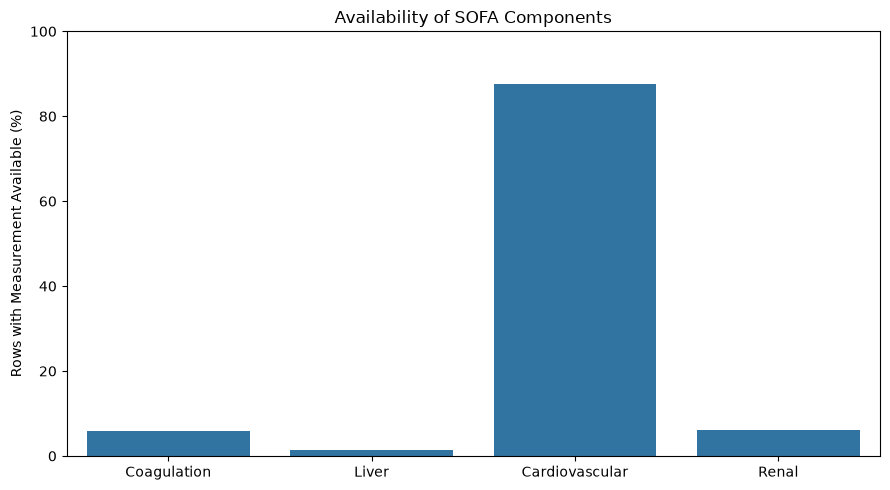

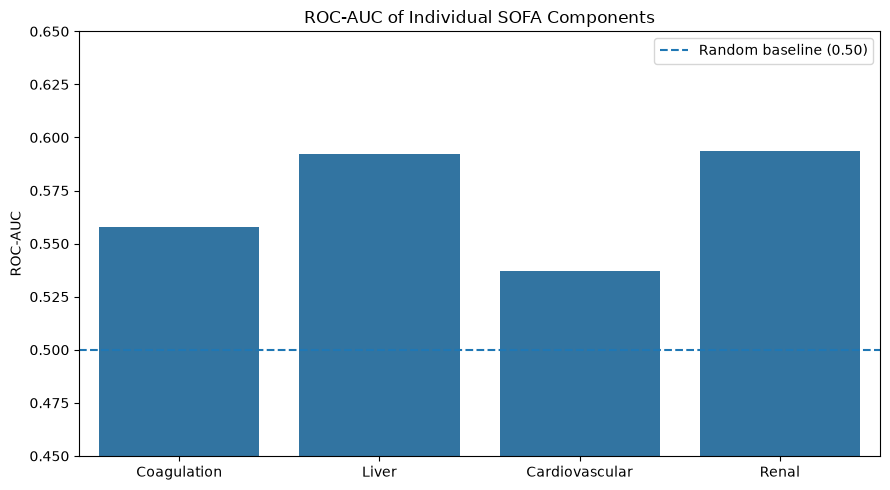

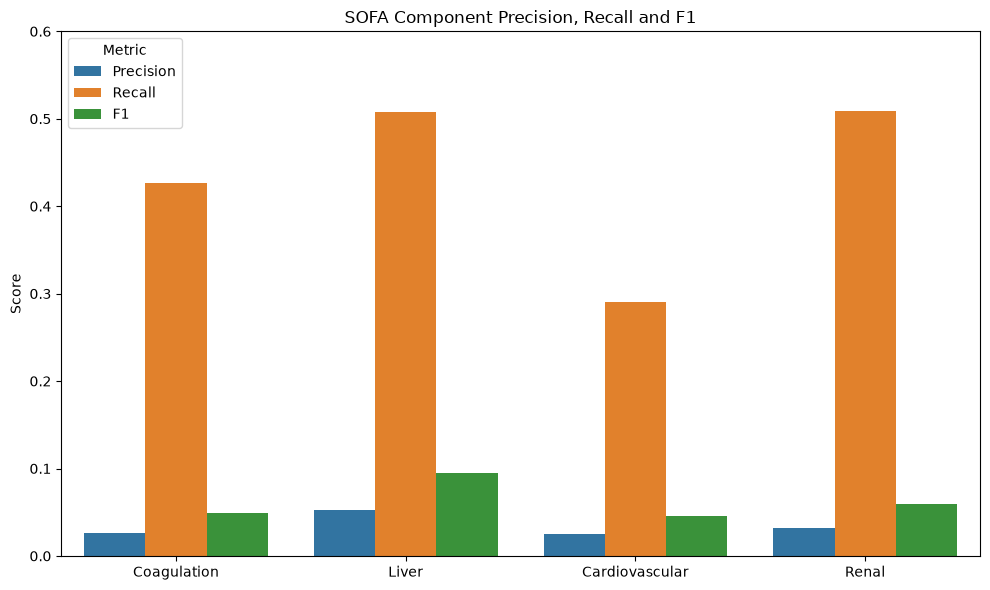

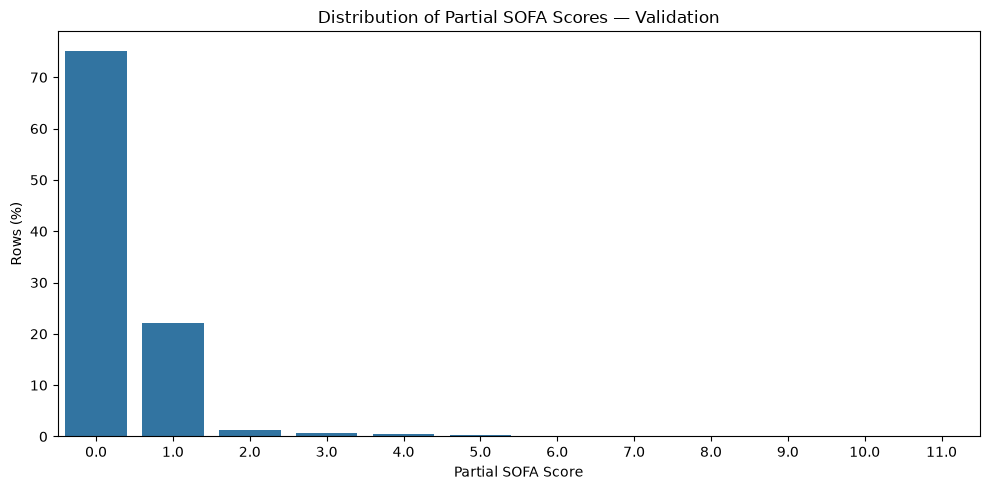

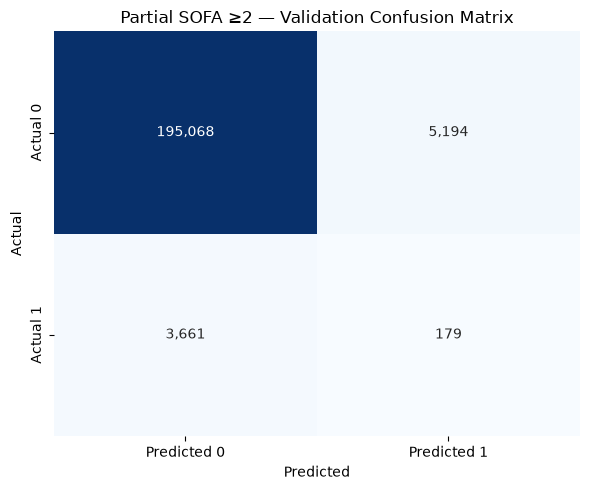

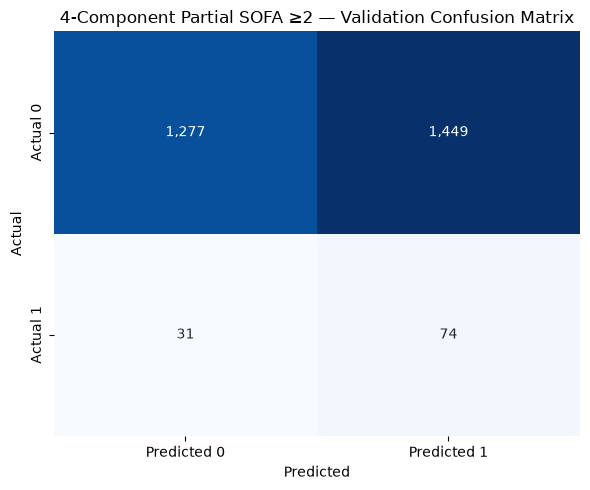

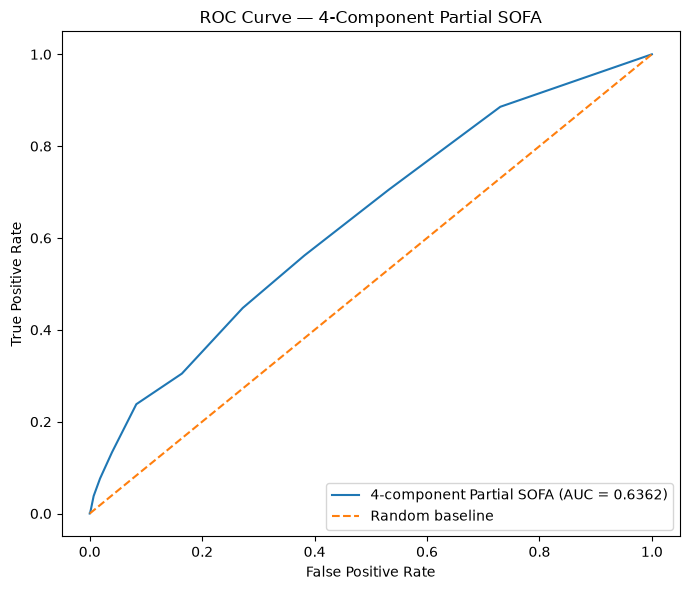

,Item,Result
0,SOFA type,Modified / partial SOFA
1,Canonical SOFA reproducible?,No
2,Validation rows with ≥1 component,"204,102"
3,Validation rows with all 4 available components,"2,831"
4,Partial SOFA ≥2 — Recall,0.0466
5,Partial SOFA ≥2 — Precision,0.0333
6,Partial SOFA ≥2 — F1,0.0389
7,4-component Partial SOFA ≥2 — Recall,0.7048
8,4-component Partial SOFA ≥2 — Precision,0.0486
9,4-component Partial SOFA ≥2 — F1,0.0909



SOFA BASELINE — INTERPRETATION

This analysis uses a modified/partial SOFA score because the
PhysioNet dataset does not contain all variables required for
canonical six-component SOFA.

Unavailable canonical SOFA variables:
- PaO2
- GCS
- Urine output
- Vasopressor measurements

Available components used:
- Platelets
- Bilirubin
- MAP
- Creatinine

Missingness is substantial. Most validation observations have
only one available component, while approximately 1.2% have all
four available components.

Therefore, the results should NOT be interpreted as performance
of canonical SOFA.

The primary exploratory rule was:
    Partial SOFA >= 2

A secondary analysis evaluated the same threshold only among
observations where all four available components were present.

The complete-component analysis showed stronger recall and
discrimination, but it represents a small and potentially
non-random subset of observations.

The SOFA baseline is therefore best interpreted as a clinical
rule-based re

In [18]:
# ============================================================
# CELL 18 — FINAL SOFA RESULTS & VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# ------------------------------------------------------------
# 1. Individual SOFA component results
# ------------------------------------------------------------

display(
    component_results_df.style.format({
        "Available_Rows": "{:,.0f}",
        "Positive_Rows": "{:,.0f}",
        "Positive_Rate_%": "{:.2f}%",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}"
    }).set_caption(
        "Individual Available SOFA Component Performance — Validation"
    )
)


# ------------------------------------------------------------
# 2. Overall partial SOFA rule
# ------------------------------------------------------------

overall_sofa_results = pd.DataFrame([
    {
        "Analysis": "Partial SOFA >= 2",
        "Rows_Evaluated": partial_sofa_metrics["Rows_Evaluated"],
        "Positive_Rate_%": partial_sofa_metrics["Positive_Rate_%"],
        "Accuracy": partial_sofa_metrics["Accuracy"],
        "Precision": partial_sofa_metrics["Precision"],
        "Recall": partial_sofa_metrics["Recall"],
        "F1": partial_sofa_metrics["F1"],
        "ROC_AUC": np.nan
    },
    {
        "Analysis": "4-component Partial SOFA >= 2",
        "Rows_Evaluated": complete_sofa_metrics["Rows_Evaluated"],
        "Positive_Rate_%": complete_sofa_metrics["Positive_Rate_%"],
        "Accuracy": complete_sofa_metrics["Accuracy"],
        "Precision": complete_sofa_metrics["Precision"],
        "Recall": complete_sofa_metrics["Recall"],
        "F1": complete_sofa_metrics["F1"],
        "ROC_AUC": complete_sofa_metrics["ROC_AUC"]
    }
])

display(
    overall_sofa_results.style.format({
        "Rows_Evaluated": "{:,.0f}",
        "Positive_Rate_%": "{:.2f}%",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": lambda x: "" if pd.isna(x) else f"{x:.4f}"
    }).set_caption(
        "Partial SOFA Baseline Performance — Validation"
    )
)


# ------------------------------------------------------------
# 3. Component availability visualization
# ------------------------------------------------------------

availability_plot_df = component_summary_df[
    ["Component", "Availability_%"]
].copy()

plt.figure(figsize=(9, 5))

sns.barplot(
    data=availability_plot_df,
    x="Component",
    y="Availability_%"
)

plt.title("Availability of SOFA Components")
plt.xlabel("")
plt.ylabel("Rows with Measurement Available (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Individual component ROC-AUC comparison
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    data=component_results_df,
    x="Component",
    y="ROC_AUC"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Random baseline (0.50)"
)

plt.title("ROC-AUC of Individual SOFA Components")
plt.xlabel("")
plt.ylabel("ROC-AUC")
plt.ylim(0.45, 0.65)
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Precision / Recall / F1 comparison
# ------------------------------------------------------------

component_metric_plot = component_results_df.melt(
    id_vars="Component",
    value_vars=["Precision", "Recall", "F1"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=component_metric_plot,
    x="Component",
    y="Score",
    hue="Metric"
)

plt.title("SOFA Component Precision, Recall and F1")
plt.xlabel("")
plt.ylabel("Score")
plt.ylim(0, 0.60)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Partial SOFA score distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.barplot(
    data=partial_score_distribution,
    x="Partial_SOFA",
    y="Percentage"
)

plt.title("Distribution of Partial SOFA Scores — Validation")
plt.xlabel("Partial SOFA Score")
plt.ylabel("Rows (%)")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Overall Partial SOFA confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

sns.heatmap(
    partial_sofa_cm_df,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False
)

plt.title("Partial SOFA ≥2 — Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Complete 4-component confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

sns.heatmap(
    complete_sofa_cm_df,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False
)

plt.title(
    "4-Component Partial SOFA ≥2 — Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Exploratory ROC curve for complete 4-component score
# ------------------------------------------------------------

complete_y_true = complete_sofa_val["SepsisLabel"]
complete_y_score = complete_sofa_val["Partial_SOFA"]

fpr, tpr, thresholds = roc_curve(
    complete_y_true,
    complete_y_score
)

complete_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"4-component Partial SOFA (AUC = {complete_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.title(
    "ROC Curve — 4-Component Partial SOFA"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Final report-ready summary
# ------------------------------------------------------------

final_sofa_summary = pd.DataFrame({
    "Item": [
        "SOFA type",
        "Canonical SOFA reproducible?",
        "Validation rows with ≥1 component",
        "Validation rows with all 4 available components",
        "Partial SOFA ≥2 — Recall",
        "Partial SOFA ≥2 — Precision",
        "Partial SOFA ≥2 — F1",
        "4-component Partial SOFA ≥2 — Recall",
        "4-component Partial SOFA ≥2 — Precision",
        "4-component Partial SOFA ≥2 — F1",
        "4-component Partial SOFA — ROC-AUC"
    ],
    "Result": [
        "Modified / partial SOFA",
        "No",
        f"{len(sofa_eval_df):,}",
        f"{len(complete_sofa_val):,}",
        f"{partial_sofa_metrics['Recall']:.4f}",
        f"{partial_sofa_metrics['Precision']:.4f}",
        f"{partial_sofa_metrics['F1']:.4f}",
        f"{complete_sofa_metrics['Recall']:.4f}",
        f"{complete_sofa_metrics['Precision']:.4f}",
        f"{complete_sofa_metrics['F1']:.4f}",
        f"{complete_sofa_metrics['ROC_AUC']:.4f}"
    ]
})

display(
    final_sofa_summary.style.set_caption(
        "Final SOFA Baseline Summary — Validation"
    )
)


# ------------------------------------------------------------
# 11. Methodological interpretation
# ------------------------------------------------------------

print("""
============================================================
SOFA BASELINE — INTERPRETATION
============================================================

This analysis uses a modified/partial SOFA score because the
PhysioNet dataset does not contain all variables required for
canonical six-component SOFA.

Unavailable canonical SOFA variables:
- PaO2
- GCS
- Urine output
- Vasopressor measurements

Available components used:
- Platelets
- Bilirubin
- MAP
- Creatinine

Missingness is substantial. Most validation observations have
only one available component, while approximately 1.2% have all
four available components.

Therefore, the results should NOT be interpreted as performance
of canonical SOFA.

The primary exploratory rule was:
    Partial SOFA >= 2

A secondary analysis evaluated the same threshold only among
observations where all four available components were present.

The complete-component analysis showed stronger recall and
discrimination, but it represents a small and potentially
non-random subset of observations.

The SOFA baseline is therefore best interpreted as a clinical
rule-based reference point rather than a direct equivalent of
canonical SOFA.
============================================================
""")